# Generating Embeddings using Hugging Face (Free models)

**Level:** Scratch → Intermediate
**Runs on:** Google Colab (Free CPU/GPU)

### What you will learn
1. What an embedding is (in simple words)
2. Installing free, open Hugging Face libraries
3. Generating embeddings with `sentence-transformers`
4. Comparing text similarity using cosine similarity
5. Visualizing embeddings in 2D
6. Building a mini Semantic Search engine (intermediate project)

> No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.

## 1. What is an Embedding?

- An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text.
- Similar sentences → similar (close) vectors.
- Different sentences → far apart vectors.

Example:
- "I love dogs" and "I like puppies" → vectors will be **close**
- "I love dogs" and "The stock market crashed" → vectors will be **far apart**

We will use the `sentence-transformers` library, which uses free Hugging Face models.

### 2. Install Required Libraries
Run this once. `-q` keeps the output quiet (low token / clean output).

In [2]:
!pip install sentence-transformers

In [3]:
!pip install -q sentence-transformers scikit-learn matplotlib

### 3. Load a Free Hugging Face Model

We are using **`all-MiniLM-L6-v2`** — a small, fast, completely free open-source model from Hugging Face.
- Size: ~80MB
- Great for learning and even production use
- Output: 384-dimensional embedding vector per sentence

In [5]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


### 4. Generate Your First Embedding

In [6]:
sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634455 -0.0765703   0.04107474  0.01962832  0.05804764 -0.05071755
  0.03889348  0.03076576  0.05800403  0.06948569]


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the *meaning* of the sentence.

### 5. Generate Embeddings for Multiple Sentences

In [7]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


### 6. Measure Similarity Between Sentences

We use **Cosine Similarity** to check how close two embeddings are.
- Score close to `1` → very similar meaning
- Score close to `0` → unrelated meaning
- Score close to `-1` → opposite meaning (rare with text)

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


**Important Discussion Point:**
Look at the similarity score between *"I love dogs"* and *"I like puppies"* — it should be high.
Compare that to *"I love dogs"* vs *"The stock market crashed today"* — it should be low.

This is the **core idea behind semantic search, chatbots, and recommendation systems**.

### 7. Visualize Embeddings in 2D (using PCA)
Embeddings have 384 dimensions — we can't see that. So we reduce it to 2D just to *visualize* how sentences cluster.

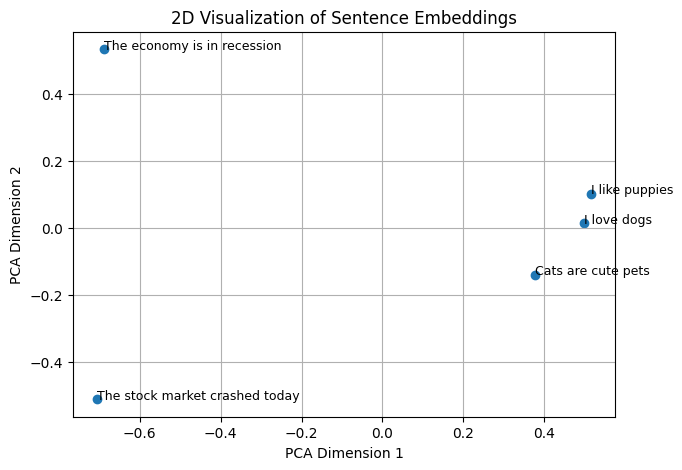

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear **closer together** in the plot, even though we never told the model to group them manually.

## 8. Intermediate Project: Mini Semantic Search Engine

**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.

In [10]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")

Query: Tell me about AI and neural networks

Score: 0.534  |  Deep learning uses neural networks with many layers.
Score: 0.524  |  Python is a popular programming language for AI.


In [11]:
# Try another query
semantic_search("What is the capital of France?")

Query: What is the capital of France?

Score: 0.824  |  Paris is the capital city of France.
Score: 0.102  |  Python is a popular programming language for AI.


### 9. Key Takeaways (Recap for Students)

| Concept | Meaning |
|---|---|
| Embedding | Numeric vector representing meaning of text |
| Model used | `all-MiniLM-L6-v2` (free, open-source, Hugging Face) |
| Cosine Similarity | Measures how close two embeddings are |
| Semantic Search | Finding relevant text by meaning, not exact words |
| PCA | Used only to visualize high-dimension vectors in 2D |

### 10. Practice Exercises (for students)
1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.
2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.
3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.

In [12]:
# New documents

documents = [
    "Artificial Intelligence is transforming industries.",
    "Machine Learning is a subset of AI.",
    "Deep Learning uses neural networks.",
    "Python is popular for data science.",
    "Natural Language Processing helps computers understand text.",
    "Computer Vision analyzes images and videos.",
    "Generative AI can create text and images.",
    "ChromaDB is a vector database.",
    "Embeddings convert text into vectors.",
    "Semantic search finds meaning rather than keywords."
]

# Create embeddings
document_embeddings = model.encode(documents)

# Semantic search function
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, documents, embeddings, top_k=3):
    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    print(f"Query: {query}\n")

    for idx in top_indices:
        print(f"Score: {similarities[idx]:.4f}")
        print(f"Document: {documents[idx]}\n")

# Test
semantic_search(
    "How do computers understand human language?",
    documents,
    document_embeddings
)

Query: How do computers understand human language?

Score: 0.6413
Document: Natural Language Processing helps computers understand text.

Score: 0.3861
Document: Computer Vision analyzes images and videos.

Score: 0.3539
Document: Deep Learning uses neural networks.



In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import time

# Documents
documents = [
    "Artificial Intelligence is transforming industries.",
    "Machine Learning is a subset of AI.",
    "Deep Learning uses neural networks.",
    "Python is popular for data science.",
    "Natural Language Processing helps computers understand text.",
    "Computer Vision analyzes images and videos.",
    "Generative AI can create text and images.",
    "ChromaDB is a vector database.",
    "Embeddings convert text into vectors.",
    "Semantic search finds meaning rather than keywords."
]

query = "How do computers understand human language?"

# Compare both models
models = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2"
]

for model_name in models:
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")

    start_time = time.time()

    model = SentenceTransformer(model_name)

    document_embeddings = model.encode(documents)
    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        document_embeddings
    )[0]

    top_indices = similarities.argsort()[-3:][::-1]

    print(f"\nQuery: {query}\n")

    for idx in top_indices:
        print(f"Score: {similarities[idx]:.4f}")
        print(f"Document: {documents[idx]}\n")

    end_time = time.time()

    print(f"Execution Time: {end_time - start_time:.2f} seconds")


Model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Query: How do computers understand human language?

Score: 0.6413
Document: Natural Language Processing helps computers understand text.

Score: 0.3861
Document: Computer Vision analyzes images and videos.

Score: 0.3539
Document: Deep Learning uses neural networks.

Execution Time: 2.01 seconds

Model: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Query: How do computers understand human language?

Score: 0.5695
Document: Natural Language Processing helps computers understand text.

Score: 0.3848
Document: Deep Learning uses neural networks.

Score: 0.3715
Document: Semantic search finds meaning rather than keywords.

Execution Time: 11.13 seconds


In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# FAQ Questions
questions = [
    "What is Artificial Intelligence?",
    "What is Machine Learning?",
    "What is Deep Learning?",
    "What are Embeddings?",
    "What is ChromaDB?"
]

# FAQ Answers
answers = [
    "Artificial Intelligence is the simulation of human intelligence by machines.",
    "Machine Learning is a subset of AI that enables systems to learn from data.",
    "Deep Learning is a subset of Machine Learning that uses neural networks.",
    "Embeddings are numerical vector representations of text used in semantic search.",
    "ChromaDB is an open-source vector database designed for AI applications."
]

# Create embeddings for FAQ questions
question_embeddings = model.encode(questions)

# FAQ Bot Function
def faq_bot(user_question):
    user_embedding = model.encode([user_question])

    similarities = cosine_similarity(
        user_embedding,
        question_embeddings
    )[0]

    best_match_index = similarities.argmax()

    print("User Question:", user_question)
    print("\nBest Matching FAQ:")
    print("Question:", questions[best_match_index])
    print("Answer:", answers[best_match_index])
    print("Similarity Score:", round(similarities[best_match_index], 4))

# Test the FAQ Bot
faq_bot("Can you explain vector embeddings?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

User Question: Can you explain vector embeddings?

Best Matching FAQ:
Question: What are Embeddings?
Answer: Embeddings are numerical vector representations of text used in semantic search.
Similarity Score: 0.7963
